<a href="https://colab.research.google.com/github/ss48/opencv/blob/master/OpenCV_ML1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image classification
Load image data.

Use OpenCV to inspect and preprocess images.

Convert images into numbers/features that a model can learn from.

Train a machine learning classifier.

Test and evaluate how well it predicts.
load images → preprocess with OpenCV → convert to features → train ML model → predict digits → evaluate results

For each image, the code:

converts it to OpenCV-friendly format

1.resizes it from 8×8 to 32×32

2.applies Gaussian blur to smooth it

3.flattens the 2D image into a 1D list of numbers

That flattened list becomes the input features for the machine learning model.

In [2]:
!pip install -q opencv-python-headless scikit-learn matplotlib numpy
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab.patches import cv2_imshow
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [3]:
digits = load_digits()

images = digits.images   # shape: (1797, 8, 8)
labels = digits.target   # shape: (1797,)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Classes:", np.unique(labels))


Images shape: (1797, 8, 8)
Labels shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


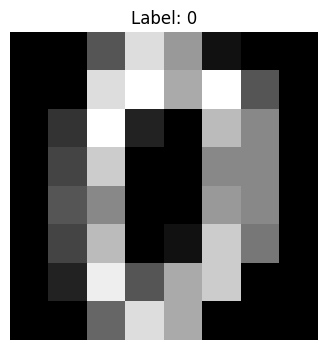

In [7]:
sample = images[0]

plt.figure(figsize=(4,4))
plt.imshow(sample, cmap="gray", interpolation="nearest")
plt.title(f"Label: {labels[0]}")
plt.axis("off")
plt.show()


In [8]:
processed_features = []

for img in images:
    # Convert to uint8 in 0-255 range
    img_uint8 = (img / img.max() * 255).astype(np.uint8)

    # Resize with OpenCV
    resized = cv2.resize(img_uint8, (32, 32), interpolation=cv2.INTER_CUBIC)

    # Light smoothing
    blurred = cv2.GaussianBlur(resized, (3, 3), 0)

    # Flatten into a 1D feature vector
    feature_vector = blurred.flatten()
    processed_features.append(feature_vector)

X = np.array(processed_features)
y = labels

print("Feature matrix shape:", X.shape)


Feature matrix shape: (1797, 1024)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (1437, 1024)
Test size: (360, 1024)


In [10]:
model = SVC(kernel="rbf", gamma="scale")
model.fit(X_train, y_train)


SVC()

In [11]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9861111111111112

Classification report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.95      0.97      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      1.00      1.00        36
           7       0.97      1.00      0.99        36
           8       1.00      0.94      0.97        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



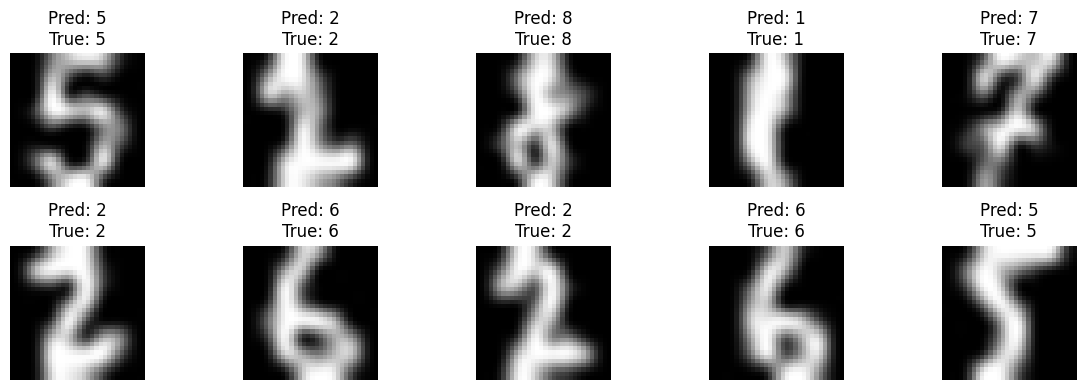

In [12]:
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = X_test[i].reshape(32, 32)
    plt.imshow(img, cmap="gray")
    plt.title(f"Pred: {y_pred[i]}\nTrue: {y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


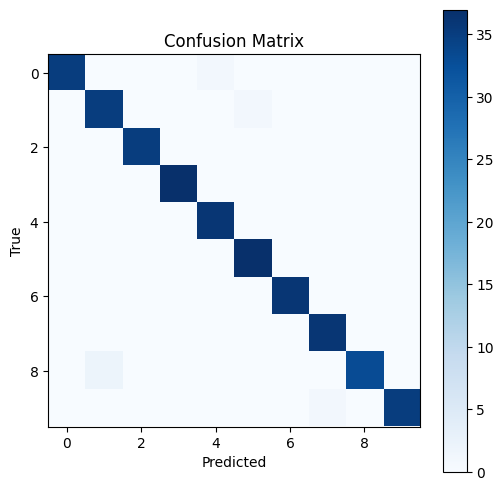

[[35  0  0  0  1  0  0  0  0  0]
 [ 0 35  0  0  0  1  0  0  0  0]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 37  0  0  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 37  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  2  0  0  0  0  0  0 33  0]
 [ 0  0  0  0  0  0  0  1  0 35]]


In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

print(cm)
